# Minimizing Peak Post-Match Queues  
## Optimal Bus Dispatch Scheduling for Stadium Egress at MetLife Stadium


### Decision Variables
- $x_t$ = buses dispatched in interval $t$
- $y_t$ = passengers served in interval $t$
- $q_t$ = queue at end of interval $t$
- $z$ = maximum queue over all intervals

### Parameters
- $D_t$: outbound passenger demand arriving in interval $t$
- $R_t$: fixed rail capacity available in interval $t$
- $B$: total number of supporting shuttle buses
- $C_b$: effective passenger capacity per dispatched bus
- $\tau$: average bus turnaround time, modeled using scenario-based assumptions
- $h = \tau/15$: turnaround time expressed in 15-minute intervals
- $L$: maximum buses loaded and dispatched in one interval
- $Q_0$: initial queue at the start of post-match operations

In [ ]:
import pulp
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Base-Case Inputs

- total outbound demand = 24,000
- rail capacity = 1,300 passengers per interval
- supporting buses = 60
- bus capacity = 55 passengers
- turnaround time = 60 minutes
- turnaround time in 15-interval = $h$ = 60/15 = 4
- loading limit = 18 buses per interval
- initial queue = 0

In [ ]:
T = list(range(1, 13)) # a list of interval from 1 to 12

demand_profile = np.array([0.18, 0.17, 0.15, 0.12, 0.10, 0.08, 0.06, 0.05, 0.04, 0.02, 0.02, 0.01]) # percentage of total outbound demand that arrives in each interval (from the proposal)
total_demand = 24000
rail_capacity = 1300
B = 60
Cb = 55
tau = 60
h = tau // 15
L = 18
Q0 = 0

raw_demand = total_demand * demand_profile
D_list = np.floor(raw_demand).astype(int) # rounding demand down
difference = int(total_demand - D_list.sum()) # check if rounding changed total demand
remainders = raw_demand - np.floor(raw_demand) # how many passengers are “missing” because of rounding
order = np.argsort(-remainders) # sort intervals by largest remainder
for i in range(difference):
    D_list[order[i]] += 1 # add back missing passengers

D = {t: int(D_list[t-1]) for t in T} # turn the demand and rail capacity into dictionary for later use
R = {t: rail_capacity for t in T}

print('Total demand:', sum(D.values()))
print('Turnaround intervals h:', h)
print(D)

Total demand: 24000
Turnaround intervals h: 4
{1: 4320, 2: 4080, 3: 3600, 4: 2880, 5: 2400, 6: 1920, 7: 1440, 8: 1200, 9: 960, 10: 480, 11: 480, 12: 240}


## Mathematical Model

Objective:
$$
\min \; M (z) + \sum_{t=1}^{T} q_t
$$

Subject to:
$$
q_1 = Q_0 + D_1 - y_1
$$

$$
q_t = q_{t-1} + D_t - y_t \quad t=2,\dots,T
$$

$$
y_t \le R_t + C_b x_t
$$

$$
y_1 \le Q_0 + D_1
$$

$$
y_t \le q_{t-1} + D_t \quad t=2,\dots,T
$$

$$
z \ge q_t \quad \forall t
$$

$$
x_t \le L \quad \forall t
$$

$$
\sum_{\tau = \max(1, t-h+1)}^{t} x_\tau \le B \quad \forall t
$$

In [ ]:
prob = pulp.LpProblem('MetLife_Bus_Dispatch', pulp.LpMinimize)

x = pulp.LpVariable.dicts('BusesDispatched', T, lowBound=0, cat='Integer')
y = pulp.LpVariable.dicts('PassengersServed', T, lowBound=0, cat='Continuous')
q = pulp.LpVariable.dicts('Queue', T, lowBound=0, cat='Continuous')
z = pulp.LpVariable('MaxQueue', lowBound=0, cat='Continuous')

Weight = 10**6
prob += Weight * z + pulp.lpSum(q[t] for t in T)

# queue evolution constraints
prob += q[1] == Q0 + D[1] - y[1]
for t in T[1:]:
    prob += q[t] == q[t-1] + D[t] - y[t]

# service capacity constraints
for t in T:
    prob += y[t] <= R[t] + Cb * x[t]

# demand availability constraints
prob += y[1] <= Q0 + D[1]
for t in T[1:]:
    prob += y[t] <= q[t-1] + D[t]

# z is forced to equal the maximum by the >= constraints. Minimizing Z gives us the minimum possible maximum value.
for t in T:
    prob += z >= q[t]
    prob += x[t] <= L  #Loading limit constraint

# fleet availability with turnaround
for t in T:
    active_intervals = [s for s in T if max(1, t-h+1) <= s <= t]
    prob += pulp.lpSum(x[s] for s in active_intervals) <= B

prob.solve(pulp.PULP_CBC_CMD(msg=False))

print('Status:', pulp.LpStatus[prob.status])
print('Peak Queue:', pulp.value(z))

Status: Optimal
Peak Queue: 6490.0


In [ ]:
# Extract results table
results = pd.DataFrame({
    'Interval': T,
    'Demand': [D[t] for t in T],
    'RailCapacity': [R[t] for t in T],
    'BusesDispatched': [pulp.value(x[t]) for t in T],
    'PassengersServed': [pulp.value(y[t]) for t in T],
    'QueueEnd': [pulp.value(q[t]) for t in T]
})

results['BusCapacityAdded'] = results['BusesDispatched'] * Cb
results['TotalCapacity'] = results['RailCapacity'] + results['BusCapacityAdded']
results

,Interval,Demand,RailCapacity,BusesDispatched,PassengersServed,QueueEnd,BusCapacityAdded,TotalCapacity
0,1,4320,1300,18.0,2290.0,2030.0,990.0,2290.0
1,2,4080,1300,18.0,2290.0,3820.0,990.0,2290.0
2,3,3600,1300,18.0,2290.0,5130.0,990.0,2290.0
3,4,2880,1300,6.0,1630.0,6380.0,330.0,1630.0
4,5,2400,1300,18.0,2290.0,6490.0,990.0,2290.0
5,6,1920,1300,18.0,2290.0,6120.0,990.0,2290.0
6,7,1440,1300,18.0,2290.0,5270.0,990.0,2290.0
7,8,1200,1300,6.0,1630.0,4840.0,330.0,1630.0
8,9,960,1300,18.0,2290.0,3510.0,990.0,2290.0
9,10,480,1300,18.0,2290.0,1700.0,990.0,2290.0


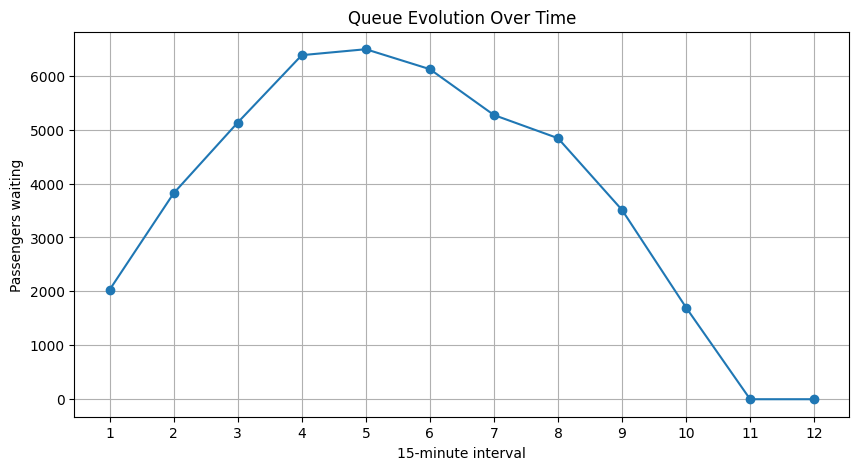

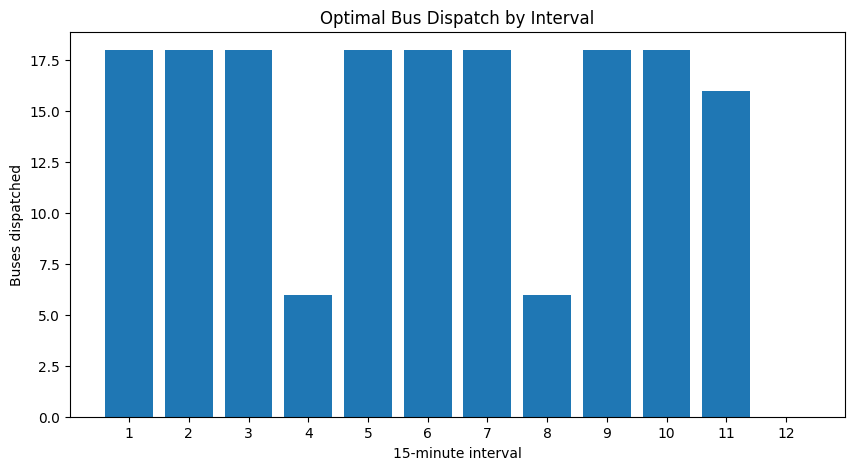

In [ ]:
# Visualization: This graph shows how the queue changes over time.
plt.figure(figsize=(10,5))
plt.plot(results['Interval'], results['QueueEnd'], marker='o')
plt.xlabel('15-minute interval')
plt.ylabel('Passengers waiting')
plt.title('Queue Evolution Over Time')
plt.xticks(T)
plt.grid(True)
plt.show()

plt.figure(figsize=(10,5))
plt.bar(results['Interval'], results['BusesDispatched'])
plt.xlabel('15-minute interval')
plt.ylabel('Buses dispatched')
plt.title('Optimal Bus Dispatch by Interval')
plt.xticks(T)
plt.show()

## Scenario Analysis Function


In [ ]:
# Compare low / base / high scenarios.
def solve_dispatch_model(total_demand, demand_profile, rail_capacity, B, Cb, tau, L, Q0=0):
    T = list(range(1, 13))
    h = tau // 15

    raw_demand = total_demand * np.array(demand_profile)
    D_list = np.floor(raw_demand).astype(int)
    difference = int(total_demand - D_list.sum())
    remainders = raw_demand - np.floor(raw_demand)
    order = np.argsort(-remainders)
    for i in range(difference):
        D_list[order[i]] += 1

    D = {t: int(D_list[t-1]) for t in T}
    R = {t: rail_capacity for t in T}

    prob = pulp.LpProblem('MetLife_Bus_Dispatch', pulp.LpMinimize)
    x = pulp.LpVariable.dicts('BusesDispatched', T, lowBound=0, cat='Integer')
    y = pulp.LpVariable.dicts('PassengersServed', T, lowBound=0, cat='Continuous')
    q = pulp.LpVariable.dicts('Queue', T, lowBound=0, cat='Continuous')
    z = pulp.LpVariable('MaxQueue', lowBound=0, cat='Continuous')

    prob += 10**6 * z + pulp.lpSum(q[t] for t in T)

    prob += q[1] == Q0 + D[1] - y[1]
    for t in T[1:]:
        prob += q[t] == q[t-1] + D[t] - y[t]

    for t in T:
        prob += y[t] <= R[t] + Cb * x[t]

    prob += y[1] <= Q0 + D[1]
    for t in T[1:]:
        prob += y[t] <= q[t-1] + D[t]

    for t in T:
        prob += z >= q[t]
        prob += x[t] <= L

    for t in T:
        active_intervals = [s for s in T if max(1, t-h+1) <= s <= t]
        prob += pulp.lpSum(x[s] for s in active_intervals) <= B

    prob.solve(pulp.PULP_CBC_CMD(msg=False))

    results = pd.DataFrame({
        'Interval': T,
        'Demand': [D[t] for t in T],
        'RailCapacity': [R[t] for t in T],
        'BusesDispatched': [pulp.value(x[t]) for t in T],
        'PassengersServed': [pulp.value(y[t]) for t in T],
        'QueueEnd': [pulp.value(q[t]) for t in T]
    })

    summary = {
        'Status': pulp.LpStatus[prob.status],
        'PeakQueue': pulp.value(z),
        'TotalQueue': results['QueueEnd'].sum(),
        'TotalBusesDispatched': results['BusesDispatched'].sum(),
        'TurnaroundIntervals': h
    }
    return summary, results

In [ ]:
scenario_inputs = {
    'Low': {
        'total_demand': 20000,
        'demand_profile': [0.14, 0.13, 0.12, 0.11, 0.10, 0.09, 0.08, 0.07, 0.06, 0.04, 0.03, 0.03],
        'rail_capacity': 1050,
        'B': 45,
        'Cb': 45,
        'tau': 75,
        'L': 12
    },
    'Base': {
        'total_demand': 24000,
        'demand_profile': [0.18, 0.17, 0.15, 0.12, 0.10, 0.08, 0.06, 0.05, 0.04, 0.02, 0.02, 0.01],
        'rail_capacity': 1300,
        'B': 60,
        'Cb': 55,
        'tau': 60,
        'L': 18
    },
    'High': {
        'total_demand': 28000,
        'demand_profile': [0.23, 0.20, 0.16, 0.12, 0.09, 0.06, 0.04, 0.03, 0.02, 0.02, 0.02, 0.01],
        'rail_capacity': 1550,
        'B': 70,
        'Cb': 65,
        'tau': 45,
        'L': 24
    }
}

rows = []
for scenario, params in scenario_inputs.items():
    summary, _ = solve_dispatch_model(**params)
    summary['Scenario'] = scenario
    rows.append(summary)

pd.DataFrame(rows)[['Scenario','Status','PeakQueue','TotalQueue','TotalBusesDispatched','TurnaroundIntervals']]

,Scenario,Status,PeakQueue,TotalQueue,TotalBusesDispatched,TurnaroundIntervals
0,Low,Optimal,4945.0,43875.0,114.0,5
1,Base,Optimal,6490.0,45290.0,172.0,4
2,High,Optimal,7570.0,41810.0,210.0,3


# Demand Sensitivity Analysis


In [ ]:
# --------------------------------------------------
# DEMAND SENSITIVITY ANALYSIS
# Holding all Base scenario operating assumptions fixed
# Only total passenger demand changes
# --------------------------------------------------

# Use Base scenario assumptions as fixed operating conditions
base_params = scenario_inputs['Base'].copy()

# Different total demand levels to test
demand_levels = [18000, 20000, 22000, 24000, 26000, 28000, 30000, 32000]

sensitivity_rows = []
sensitivity_results = {}

for demand in demand_levels:
    params = base_params.copy()
    params['total_demand'] = demand

    summary, results = solve_dispatch_model(**params)

    summary['TotalDemand'] = demand
    sensitivity_rows.append(summary)

    sensitivity_results[demand] = results

# Create summary table
demand_sensitivity_table = pd.DataFrame(sensitivity_rows)

# Reorder columns
demand_sensitivity_table = demand_sensitivity_table[
    [
        'TotalDemand',
        'Status',
        'PeakQueue',
        'TotalQueue',
        'TotalBusesDispatched',
        'TurnaroundIntervals'
    ]
]

demand_sensitivity_table

,TotalDemand,Status,PeakQueue,TotalQueue,TotalBusesDispatched,TurnaroundIntervals
0,18000,Optimal,2660.0,11060.0,114.0,4
1,20000,Optimal,3900.0,20320.0,138.0,4
2,22000,Optimal,5140.0,31810.0,156.0,4
3,24000,Optimal,6490.0,45290.0,172.0,4
4,26000,Optimal,7930.0,61380.0,180.0,4
5,28000,Optimal,9370.0,79080.0,180.0,4
6,30000,Optimal,10920.0,96780.0,180.0,4
7,32000,Optimal,12520.0,114480.0,180.0,4


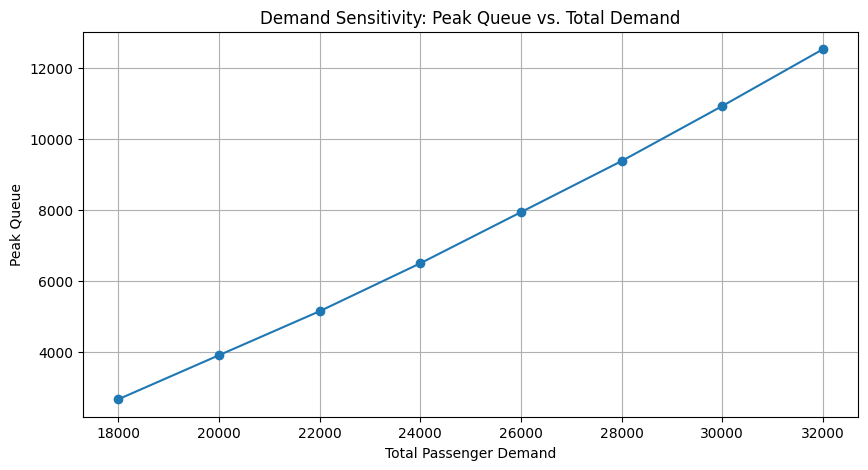

In [ ]:
# --------------------------------------------------
# VISUALIZATION 1: Peak Queue vs. Total Demand
# --------------------------------------------------

plt.figure(figsize=(10, 5))

plt.plot(
    clean_sensitivity_table['TotalDemand'],
    clean_sensitivity_table['PeakQueue'],
    marker='o'
)

plt.xlabel('Total Passenger Demand')
plt.ylabel('Peak Queue')
plt.title('Demand Sensitivity: Peak Queue vs. Total Demand')
plt.grid(True)

plt.show()

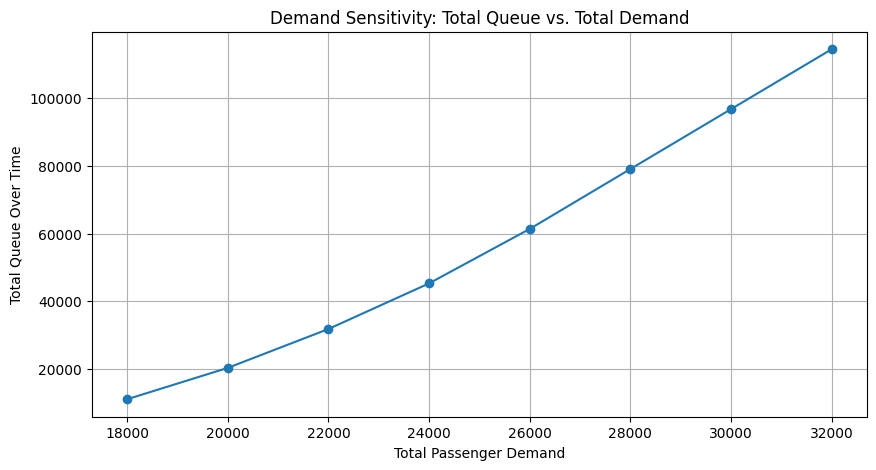

In [ ]:
# --------------------------------------------------
# VISUALIZATION 2: Total Queue vs. Total Demand
# --------------------------------------------------

plt.figure(figsize=(10, 5))

plt.plot(
    clean_sensitivity_table['TotalDemand'],
    clean_sensitivity_table['TotalQueue'],
    marker='o'
)

plt.xlabel('Total Passenger Demand')
plt.ylabel('Total Queue Over Time')
plt.title('Demand Sensitivity: Total Queue vs. Total Demand')
plt.grid(True)

plt.show()

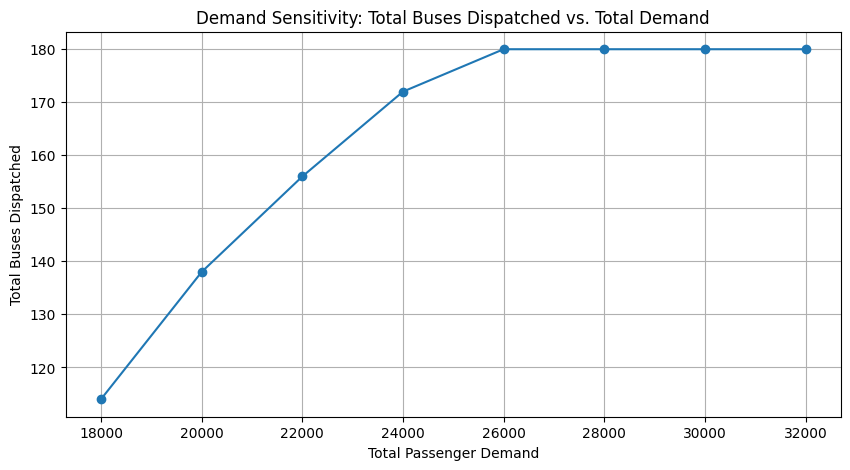

In [ ]:
# --------------------------------------------------
# VISUALIZATION 3: Total Buses Dispatched vs. Total Demand
# --------------------------------------------------

plt.figure(figsize=(10, 5))

plt.plot(
    clean_sensitivity_table['TotalDemand'],
    clean_sensitivity_table['TotalBusesDispatched'],
    marker='o'
)

plt.xlabel('Total Passenger Demand')
plt.ylabel('Total Buses Dispatched')
plt.title('Demand Sensitivity: Total Buses Dispatched vs. Total Demand')
plt.grid(True)

plt.show()

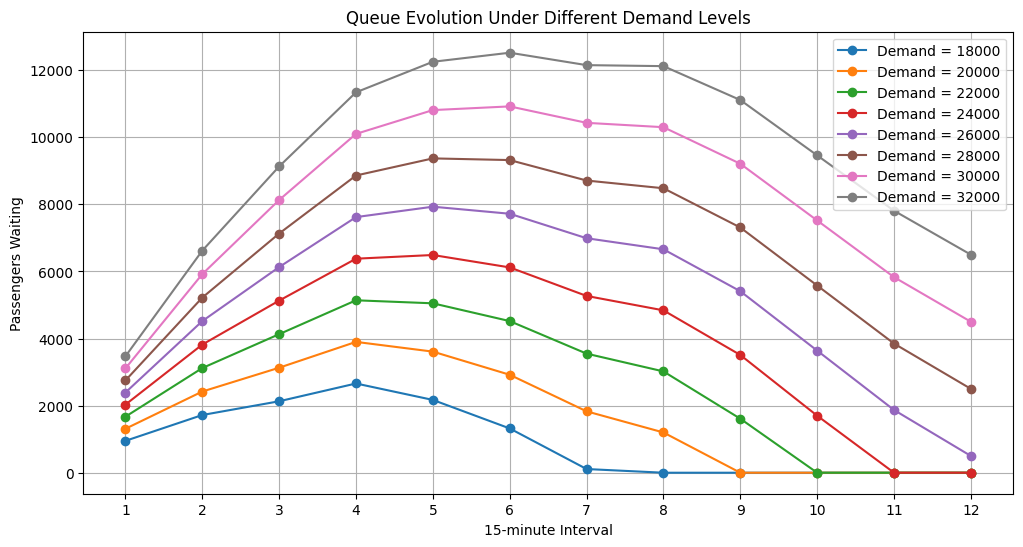

In [ ]:
# --------------------------------------------------
# VISUALIZATION 4: Queue Evolution Across Demand Levels
# --------------------------------------------------

plt.figure(figsize=(12, 6))

for demand in demand_levels:
    results = sensitivity_results[demand]

    plt.plot(
        results['Interval'],
        results['QueueEnd'],
        marker='o',
        label=f'Demand = {demand}'
    )

plt.xlabel('15-minute Interval')
plt.ylabel('Passengers Waiting')
plt.title('Queue Evolution Under Different Demand Levels')
plt.xticks(range(1, 13))
plt.grid(True)
plt.legend()

plt.show()

In [ ]:
# ============================================================
# Queue Evolution vs. Demand & Service Capacity
# Uses real values extracted directly from the solved base case
# ============================================================

import matplotlib.pyplot as plt
import numpy as np

# ── Pull real values from the solved base case model ────────────────────────
# These variables (x, y, q, D, T) already exist from your base case cell above

intervals = list(T)                                      # [1, 2, ..., 12]
demand    = [D[t] for t in T]                            # real Dt from model
served    = [pulp.value(y[t]) for t in T]                # real yt from solver
queue     = [pulp.value(q[t]) for t in T]                # real qt from solver
peak_q    = int(pulp.value(z))                           # real z* from solver
peak_t    = intervals[queue.index(max(queue))]           # interval where peak occurs

# Print to verify numbers before plotting
print("Verifying real values extracted from solver:")
print(f"{'t':>4} {'Demand':>8} {'Served':>8} {'Queue':>8}")
print("-" * 32)
for i, t in enumerate(intervals):
    print(f"{t:>4} {demand[i]:>8,.0f} {served[i]:>8,.0f} {queue[i]:>8,.0f}")
print(f"\nPeak queue z* = {peak_q:,} at interval {peak_t}")

Verifying real values extracted from solver:
   t   Demand   Served    Queue
--------------------------------
   1    4,320    2,290    2,030
   2    4,080    2,290    3,820
   3    3,600    2,290    5,130
   4    2,880    1,630    6,380
   5    2,400    2,290    6,490
   6    1,920    2,290    6,120
   7    1,440    2,290    5,270
   8    1,200    1,630    4,840
   9      960    2,290    3,510
  10      480    2,290    1,700
  11      480    2,180        0
  12      240      240        0

Peak queue z* = 6,490 at interval 5


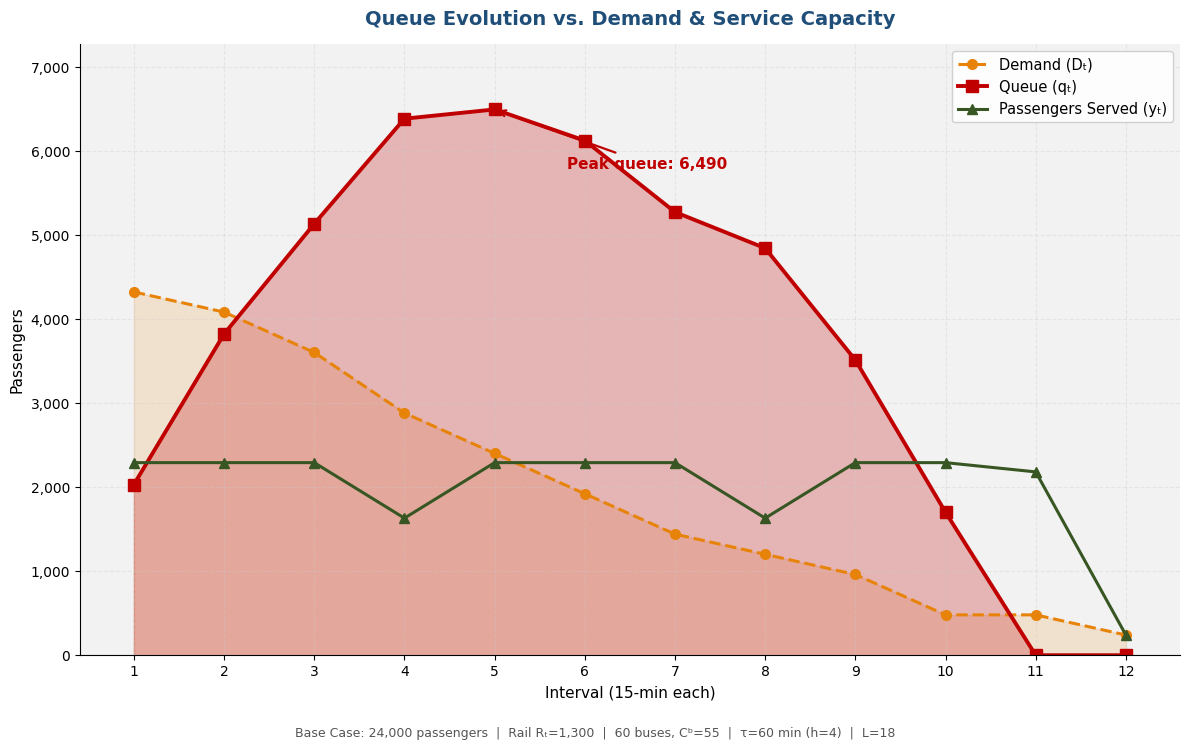

Saved: queue_evolution_real.jpg


In [ ]:
# ── Draw the chart ──────────────────────────────────────────────────────────

DARK_BLUE = "#1F4E79"
ORANGE    = "#E8830A"
RED       = "#C00000"
GREEN     = "#375623"
LGRAY     = "#F2F2F2"
MGRAY     = "#CCCCCC"
WHITE     = "white"

x = np.array(intervals)

fig, ax = plt.subplots(figsize=(12, 7.5), facecolor=WHITE)
ax.set_facecolor(LGRAY)
ax.grid(True, alpha=0.35, linestyle="--", color=MGRAY)

# Demand fill + line
ax.fill_between(x, demand, alpha=0.15, color=ORANGE)
ax.plot(x, demand, "o--", color=ORANGE, linewidth=2.2,
        markersize=7, label="Demand (D\u209C)")

# Queue fill + line
ax.fill_between(x, queue, alpha=0.25, color=RED)
ax.plot(x, queue, "s-", color=RED, linewidth=2.8,
        markersize=8, label="Queue (q\u209C)")

# Passengers served line
ax.plot(x, served, "^-", color=GREEN, linewidth=2.2,
        markersize=7, label="Passengers Served (y\u209C)")

# Peak queue annotation
peak_val = max(queue)
peak_idx = queue.index(peak_val)
ax.annotate(
    f"Peak queue: {peak_q:,}",
    xy=(x[peak_idx], peak_val),
    xytext=(x[peak_idx] + 0.8, peak_val - 700),
    fontsize=11, color=RED, fontweight="bold",
    arrowprops=dict(arrowstyle="->", color=RED, lw=1.6)
)

# Axis formatting
ax.set_title("Queue Evolution vs. Demand & Service Capacity",
             fontsize=14, fontweight="bold", color=DARK_BLUE, pad=14)
ax.set_xlabel("Interval (15-min each)", fontsize=11)
ax.set_ylabel("Passengers", fontsize=11)
ax.set_xticks(x)
ax.set_xlim(0.4, 12.6)
ax.set_ylim(0, max(max(demand), max(queue)) * 1.12)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{int(v):,}"))
ax.legend(fontsize=10.5, loc="upper right", framealpha=0.9)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Footer note with real parameters
fig.text(
    0.5, 0.01,
    f"Base Case: {sum(demand):,} passengers  |  "
    f"Rail R\u209C={rail_capacity:,}  |  "
    f"{B} buses, C\u1D47={Cb}  |  "
    f"\u03C4={tau} min (h={h})  |  L={L}",
    ha="center", fontsize=9, color="#555555"
)

fig.tight_layout(rect=[0, 0.04, 1, 1])
plt.savefig("queue_evolution_real.jpg", dpi=180, bbox_inches="tight",
            facecolor=WHITE, format="jpeg", pil_kwargs={"quality": 95})
plt.show()
print("Saved: queue_evolution_real.jpg")

In [ ]:
# ============================================================
# Capacity Deployment vs. Demand per Interval
# Extracts real values from prob.variables() — no conflicts
# ============================================================

import matplotlib.pyplot as plt
import numpy as np

# ── Pull real values safely from the solved model ────────────────────────────
var_dict   = {v.name: v.varValue for v in prob.variables()}

intervals  = list(T)
demand     = [D[t] for t in T]
rail       = [R[t] for t in T]
buses_disp = [var_dict.get(f'BusesDispatched_{t}', 0) for t in T]
bus_cap    = [Cb * var_dict.get(f'BusesDispatched_{t}', 0) for t in T]

# ── Verify before plotting ───────────────────────────────────────────────────
print(f"{'t':>4} {'Demand':>8} {'Rail':>6} {'Buses':>7} {'BusCap':>8} {'TotalCap':>10}")
print("-" * 48)
for i, t in enumerate(intervals):
    print(f"{t:>4} {demand[i]:>8,.0f} {rail[i]:>6,.0f} "
          f"{buses_disp[i]:>7,.0f} {bus_cap[i]:>8,.0f} "
          f"{rail[i]+bus_cap[i]:>10,.0f}")

   t   Demand   Rail   Buses   BusCap   TotalCap
------------------------------------------------
   1    4,320  1,300      18      990      2,290
   2    4,080  1,300      18      990      2,290
   3    3,600  1,300      18      990      2,290
   4    2,880  1,300       6      330      1,630
   5    2,400  1,300      18      990      2,290
   6    1,920  1,300      18      990      2,290
   7    1,440  1,300      18      990      2,290
   8    1,200  1,300       6      330      1,630
   9      960  1,300      18      990      2,290
  10      480  1,300      18      990      2,290
  11      480  1,300      16      880      2,180
  12      240  1,300       0        0      1,300


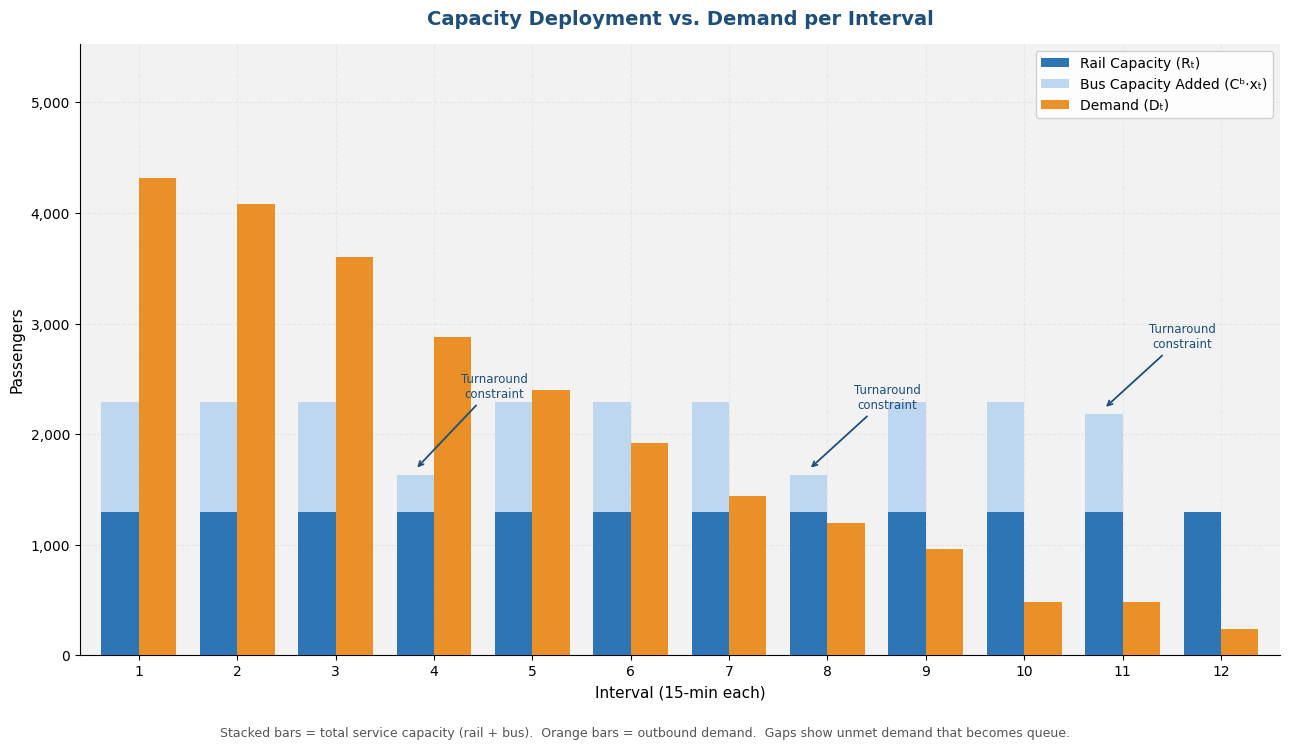

Saved: capacity_deployment_real.jpg


In [ ]:
# ── Draw the chart ───────────────────────────────────────────────────────────

DARK_BLUE  = "#1F4E79"
MED_BLUE   = "#2E75B6"
LIGHT_BLUE = "#BDD7EE"
ORANGE     = "#E8830A"
LGRAY      = "#F2F2F2"
MGRAY      = "#CCCCCC"
WHITE      = "white"

x_pos    = np.arange(1, 13)
w        = 0.38
rail_arr = np.array(rail)
bus_arr  = np.array(bus_cap)
dem_arr  = np.array(demand)

fig, ax = plt.subplots(figsize=(13, 7.5), facecolor=WHITE)
ax.set_facecolor(LGRAY)
ax.grid(True, alpha=0.3, linestyle="--", color=MGRAY, zorder=0)

# Stacked capacity bars (left of each group)
ax.bar(x_pos - w/2, rail_arr, width=w,
       color=MED_BLUE, label="Rail Capacity (R\u209C)", zorder=3)
ax.bar(x_pos - w/2, bus_arr, width=w, bottom=rail_arr,
       color=LIGHT_BLUE, label="Bus Capacity Added (C\u1D47\u00B7x\u209C)", zorder=3)

# Demand bars (right of each group)
ax.bar(x_pos + w/2, dem_arr, width=w,
       color=ORANGE, alpha=0.88, label="Demand (D\u209C)", zorder=3)

# ── Fix: detect constrained intervals by bus drop only ──────────────────────
# An interval is turnaround-constrained when buses dispatched is
# significantly below the loading limit L — regardless of demand level
max_buses = max(buses_disp)
constrained = [
    t for t in intervals
    if buses_disp[t-1] < max_buses * 0.9   # buses dropped below normal
    and buses_disp[t-1] > 0                # but still some buses running
]

# Annotation offsets tuned per interval to match original chart layout
annotation_offsets = {}
for t in constrained:
    if t <= 6:
        annotation_offsets[t] = (t - w/2 + 0.8, 700)   # right + up
    else:
        annotation_offsets[t] = (t - w/2 + 0.8, 600)   # right + up (smaller)

for t in constrained:
    cap_top = rail[t-1] + bus_cap[t-1]
    x_text_offset, y_text_offset = annotation_offsets[t]
    ax.annotate(
        "Turnaround\nconstraint",
        xy=(t - w/2, cap_top + 50),
        xytext=(x_text_offset, cap_top + y_text_offset),
        fontsize=8.5, color=DARK_BLUE, ha="center",
        arrowprops=dict(arrowstyle="->", color=DARK_BLUE, lw=1.3),
        zorder=5
    )

# Axis formatting
ax.set_title("Capacity Deployment vs. Demand per Interval",
             fontsize=14, fontweight="bold", color=DARK_BLUE, pad=14)
ax.set_xlabel("Interval (15-min each)", fontsize=11)
ax.set_ylabel("Passengers", fontsize=11)
ax.set_xticks(x_pos)
ax.set_xlim(0.4, 12.6)
ax.set_ylim(0, max(dem_arr.max(), (rail_arr + bus_arr).max()) * 1.28)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{int(v):,}"))
ax.legend(fontsize=10, loc="upper right", framealpha=0.9)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

fig.text(
    0.5, 0.01,
    "Stacked bars = total service capacity (rail + bus).  "
    "Orange bars = outbound demand.  "
    "Gaps show unmet demand that becomes queue.",
    ha="center", fontsize=9, color="#555555"
)

fig.tight_layout(rect=[0, 0.04, 1, 1])
plt.savefig("capacity_deployment_real.jpg", dpi=180, bbox_inches="tight",
            facecolor=WHITE, format="jpeg", pil_kwargs={"quality": 95})
plt.show()
print("Saved: capacity_deployment_real.jpg")

In [ ]:
# ============================================================
# Optimal Bus Dispatch Pattern per Interval (xt)
# Extracts real values from prob.variables() — no conflicts
# ============================================================

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# ── Pull real values from solved model ──────────────────────────────────────
var_dict   = {v.name: v.varValue for v in prob.variables()}
intervals  = list(T)
buses_disp = [var_dict.get(f'BusesDispatched_{t}', 0) for t in T]

# Verify
print(f"{'t':>4} {'Buses Dispatched':>18}")
print("-" * 24)
for i, t in enumerate(intervals):
    print(f"{t:>4} {buses_disp[i]:>18,.0f}")
print(f"\nLoading limit L = {L}")
print(f"Max dispatched  = {max(buses_disp):.0f}")

   t   Buses Dispatched
------------------------
   1                 18
   2                 18
   3                 18
   4                  6
   5                 18
   6                 18
   7                 18
   8                  6
   9                 18
  10                 18
  11                 16
  12                  0

Loading limit L = 18
Max dispatched  = 18


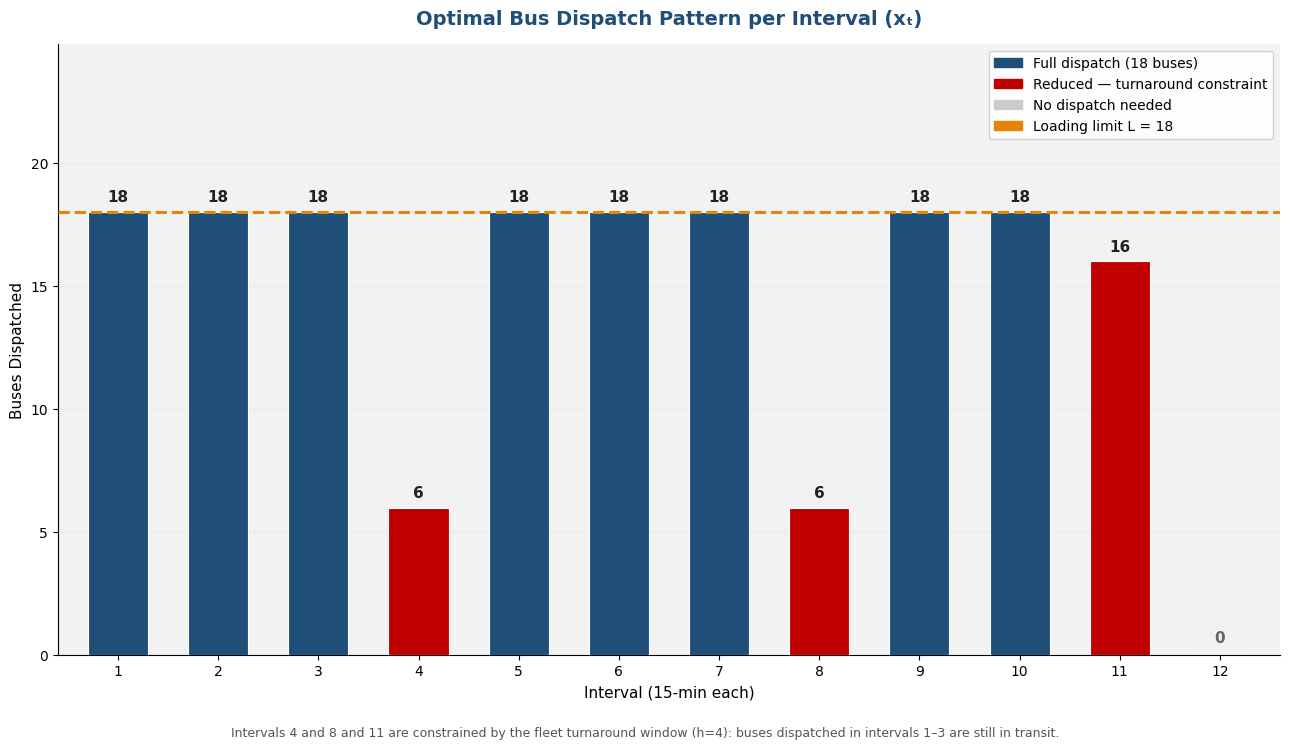

Saved: bus_dispatch_real.jpg


In [ ]:
# ── Draw the chart ───────────────────────────────────────────────────────────

DARK_BLUE = "#1F4E79"
RED       = "#C00000"
MGRAY     = "#CCCCCC"
ORANGE    = "#E8830A"
LGRAY     = "#F2F2F2"
WHITE     = "white"

max_buses = max(buses_disp)

# Color each bar:
# - Gray  → 0 buses (no dispatch needed)
# - Red   → reduced but > 0 (turnaround constrained)
# - Navy  → full dispatch (at or near loading limit)
def bar_color(b):
    if b == 0:
        return MGRAY
    elif b < max_buses * 0.9:
        return RED
    else:
        return DARK_BLUE

colors = [bar_color(b) for b in buses_disp]

x_pos = np.arange(1, 13)

fig, ax = plt.subplots(figsize=(13, 7.5), facecolor=WHITE)
ax.set_facecolor(LGRAY)
ax.grid(True, axis="y", alpha=0.3, linestyle="--", color=MGRAY, zorder=0)

bars = ax.bar(x_pos, buses_disp, color=colors, width=0.6,
              zorder=3, edgecolor=WHITE, linewidth=0.8)

# Value labels on top of each bar
for bar, val in zip(bars, buses_disp):
    if val > 0:
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.3,
                f"{int(val)}",
                ha="center", va="bottom",
                fontsize=11, fontweight="bold", color="#222222")
    else:
        ax.text(bar.get_x() + bar.get_width() / 2,
                0.4, "0",
                ha="center", va="bottom",
                fontsize=11, fontweight="bold", color="#666666")

# Loading limit dashed line
ax.axhline(L, color=ORANGE, linewidth=2.2, linestyle="--",
           zorder=4, label=f"Loading limit L = {L}")

# Legend
p_full  = mpatches.Patch(color=DARK_BLUE, label=f"Full dispatch ({L} buses)")
p_red   = mpatches.Patch(color=RED,       label="Reduced \u2014 turnaround constraint")
p_gray  = mpatches.Patch(color=MGRAY,     label="No dispatch needed")
p_limit = mpatches.Patch(color=ORANGE,    label=f"Loading limit L = {L}")
ax.legend(handles=[p_full, p_red, p_gray, p_limit],
          fontsize=10, loc="upper right", framealpha=0.9)

# Axis formatting
ax.set_title(f"Optimal Bus Dispatch Pattern per Interval (x\u209C)",
             fontsize=14, fontweight="bold", color=DARK_BLUE, pad=14)
ax.set_xlabel("Interval (15-min each)", fontsize=11)
ax.set_ylabel("Buses Dispatched", fontsize=11)
ax.set_xticks(x_pos)
ax.set_xlim(0.4, 12.6)
ax.set_ylim(0, L * 1.38)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Footer note — auto-detects which intervals are constrained
constrained_intervals = sorted([
    t for t in intervals
    if 0 < buses_disp[t-1] < max_buses * 0.9
])
constrained_str = " and ".join(str(t) for t in constrained_intervals)

fig.text(
    0.5, 0.01,
    f"Intervals {constrained_str} are constrained by the fleet turnaround window "
    f"(h={h}): buses dispatched in intervals 1\u2013{h-1} are still in transit.",
    ha="center", fontsize=9, color="#555555"
)

fig.tight_layout(rect=[0, 0.04, 1, 1])
plt.savefig("bus_dispatch_real.jpg", dpi=180, bbox_inches="tight",
            facecolor=WHITE, format="jpeg", pil_kwargs={"quality": 95})
plt.show()
print("Saved: bus_dispatch_real.jpg")

In [ ]:
# ============================================================
# Scenario Analysis: Peak Queue vs. Total Queue
# Uses real values from solve_dispatch_model — same as your
# existing scenario analysis cell
# ============================================================

import matplotlib.pyplot as plt
import numpy as np

# ── Run all three scenarios and collect real results ─────────────────────────
# scenario_inputs already defined in your notebook above
scenario_results = {}

for scenario, params in scenario_inputs.items():
    summary, _ = solve_dispatch_model(**params)
    scenario_results[scenario] = {
        'peak_queue'  : int(summary['PeakQueue']),
        'total_queue' : int(summary['TotalQueue']),
    }

# Verify real numbers before plotting
print(f"{'Scenario':<10} {'Peak Queue':>12} {'Total Queue':>13}")
print("-" * 38)
for s, res in scenario_results.items():
    print(f"{s:<10} {res['peak_queue']:>12,} {res['total_queue']:>13,}")

Scenario     Peak Queue   Total Queue
--------------------------------------
Low               4,945        43,875
Base              6,490        45,290
High              7,570        41,810


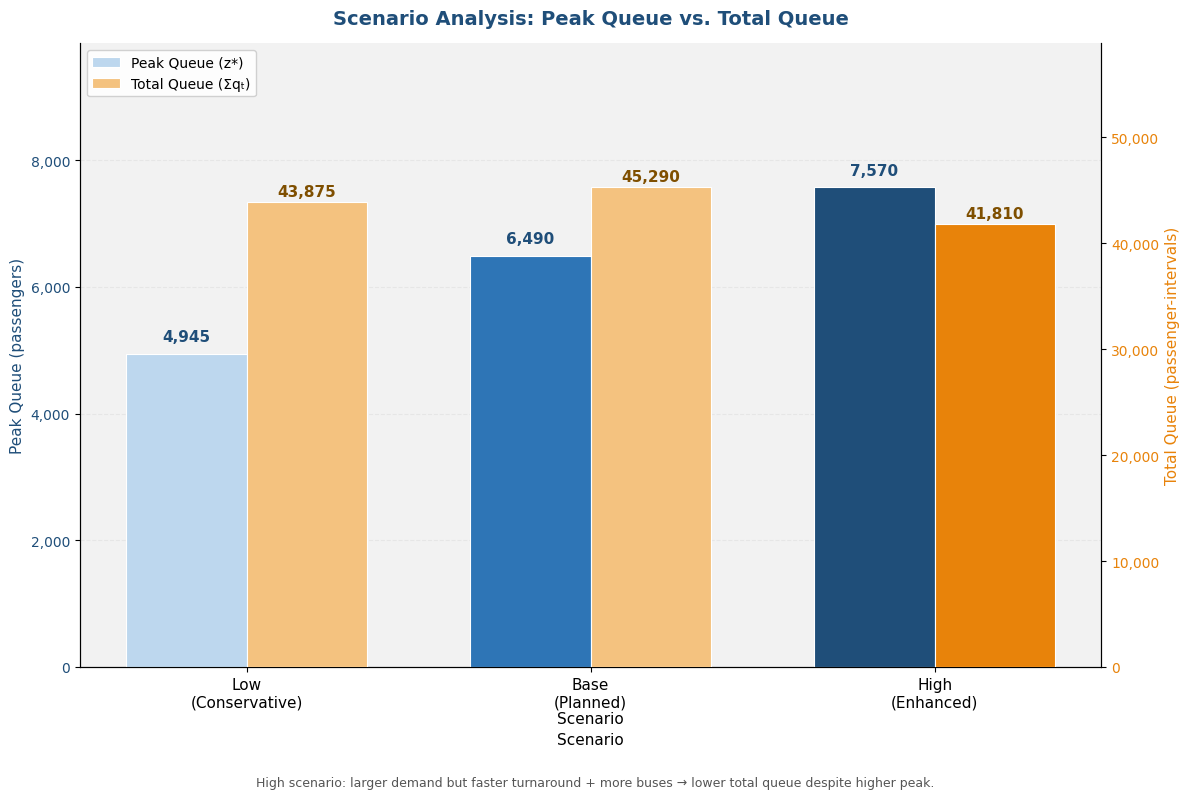

Saved: scenario_comparison_real.jpg


In [ ]:
# ── Draw the chart ───────────────────────────────────────────────────────────

DARK_BLUE  = "#1F4E79"
MED_BLUE   = "#2E75B6"
LIGHT_BLUE = "#BDD7EE"
ORANGE     = "#E8830A"
LIGHT_ORG  = "#F4C27F"
LGRAY      = "#F2F2F2"
MGRAY      = "#CCCCCC"
WHITE      = "white"

scenarios    = list(scenario_results.keys())        # ['Low', 'Base', 'High']
peak_queues  = [scenario_results[s]['peak_queue']  for s in scenarios]
total_queues = [scenario_results[s]['total_queue'] for s in scenarios]

labels = ["Low\n(Conservative)", "Base\n(Planned)\nScenario", "High\n(Enhanced)"]

# Color intensity by scenario (light → dark for peak queue bars)
peak_colors = [LIGHT_BLUE, MED_BLUE, DARK_BLUE]
total_colors = [LIGHT_ORG,  LIGHT_ORG,  ORANGE]

xs = np.arange(len(scenarios))
ww = 0.35

fig, ax = plt.subplots(figsize=(12, 8), facecolor=WHITE)
ax.set_facecolor(LGRAY)
ax.grid(True, axis="y", alpha=0.3, linestyle="--", color=MGRAY, zorder=0)

# Peak queue bars (left axis)
bars_pk = ax.bar(xs - ww/2, peak_queues, width=ww,
                 color=peak_colors, label="Peak Queue (z*)",
                 zorder=3, edgecolor=WHITE, linewidth=0.8)

# Total queue bars (right axis)
ax2 = ax.twinx()
bars_tq = ax2.bar(xs + ww/2, total_queues, width=ww,
                  color=total_colors, label="Total Queue (\u03A3q\u209C)",
                  zorder=3, edgecolor=WHITE, linewidth=0.8)

# Value labels — peak queue
for bar, val in zip(bars_pk, peak_queues):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 150,
            f"{val:,}",
            ha="center", va="bottom",
            fontsize=11, fontweight="bold", color=DARK_BLUE)

# Value labels — total queue
for bar, val in zip(bars_tq, total_queues):
    ax2.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 300,
             f"{val:,}",
             ha="center", va="bottom",
             fontsize=11, fontweight="bold", color="#7F4F00")

# Axis formatting — left
ax.set_title("Scenario Analysis: Peak Queue vs. Total Queue",
             fontsize=14, fontweight="bold", color=DARK_BLUE, pad=14)
ax.set_xlabel("Scenario", fontsize=11)
ax.set_ylabel("Peak Queue (passengers)", fontsize=11, color=DARK_BLUE)
ax.set_xticks(xs)
ax.set_xticklabels(labels, fontsize=11)
ax.set_ylim(0, max(peak_queues) * 1.30)
ax.tick_params(axis="y", labelcolor=DARK_BLUE)
ax.spines["top"].set_visible(False)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{int(v):,}"))

# Axis formatting — right
ax2.set_ylabel("Total Queue (passenger-intervals)", fontsize=11, color=ORANGE)
ax2.set_ylim(0, max(total_queues) * 1.30)
ax2.tick_params(axis="y", labelcolor=ORANGE)
ax2.spines["top"].set_visible(False)
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{int(v):,}"))

# Combined legend
ax.legend(handles=[bars_pk, bars_tq],
          labels=["Peak Queue (z*)", "Total Queue (\u03A3q\u209C)"],
          fontsize=10, loc="upper left", framealpha=0.9)

# Footer note
fig.text(
    0.5, 0.01,
    "High scenario: larger demand but faster turnaround + more buses "
    "\u2192 lower total queue despite higher peak.",
    ha="center", fontsize=9, color="#555555"
)

fig.tight_layout(rect=[0, 0.04, 1, 1])
plt.savefig("scenario_comparison_real.jpg", dpi=180, bbox_inches="tight",
            facecolor=WHITE, format="jpeg", pil_kwargs={"quality": 95})
plt.show()
print("Saved: scenario_comparison_real.jpg")

In [ ]:
# ============================================================
# SECTION 8 — One-at-a-Time (OAT) Sensitivity Analysis
# ============================================================
# Each parameter is varied independently while all others
# remain fixed at base-case values.

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# ── Base Case values (held fixed except the parameter being tested) ─────────
BASE = {
    'total_demand'   : 24000,
    'demand_profile' : [0.18, 0.17, 0.15, 0.12, 0.10, 0.08,
                        0.06, 0.05, 0.04, 0.02, 0.02, 0.01],
    'rail_capacity'  : 1300,
    'B'              : 60,
    'Cb'             : 55,
    'tau'            : 60,
    'L'              : 18,
}

BASE_Z = 6490  # base case z* already solved above

# ── Define test values for each parameter ───────────────────────────────────
oat_tests = {
    'Fleet Size (B)'      : {'param': 'B',             'values': [30, 45, 60, 75, 90]},
    'Rail Capacity (Rt)'  : {'param': 'rail_capacity', 'values': [900, 1100, 1300, 1500, 1700]},
    'Bus Capacity (Cb)'   : {'param': 'Cb',            'values': [35, 45, 55, 65, 75]},
    'Turnaround Time (t)' : {'param': 'tau',           'values': [30, 45, 60, 75, 90]},
    'Loading Limit (L)'   : {'param': 'L',             'values': [10, 12, 18, 21, 24]},
    'Total Demand (D)'    : {'param': 'total_demand',  'values': [18000, 21000, 24000, 27000, 30000]},
}

# ── Run the model for every combination ─────────────────────────────────────
print("Running OAT sensitivity analysis...")
print(f"{'Parameter':<25} {'Value':>8} {'z* (Peak Queue)':>16} {'Delta from Base':>16}")
print("-" * 68)

oat_results = {}

for label, test in oat_tests.items():
    param_name = test['param']
    results_for_param = []

    for val in test['values']:
        # Start from base case, change only one parameter
        run_params = BASE.copy()
        run_params[param_name] = val

        # Solve the model
        summary, _ = solve_dispatch_model(**run_params)
        z_star = summary['PeakQueue']
        delta  = z_star - BASE_Z
        results_for_param.append({'value': val, 'z_star': z_star, 'delta': delta})

        marker = "  <- base" if val == BASE.get(param_name) else ""
        print(f"{label:<25} {val:>8} {z_star:>16,.0f} {delta:>+16,.0f}{marker}")

    oat_results[label] = results_for_param
    print()

print("Done!")

Running OAT sensitivity analysis...
Parameter                    Value  z* (Peak Queue)  Delta from Base
--------------------------------------------------------------------
Fleet Size (B)                  30            8,240           +1,750
Fleet Size (B)                  45            7,315             +825
Fleet Size (B)                  60            6,490               +0  <- base
Fleet Size (B)                  75            5,830             -660
Fleet Size (B)                  90            5,830             -660

Rail Capacity (Rt)             900            8,520           +2,030
Rail Capacity (Rt)            1100            7,490           +1,000
Rail Capacity (Rt)            1300            6,490               +0  <- base
Rail Capacity (Rt)            1500            5,580             -910
Rail Capacity (Rt)            1700            4,780           -1,710

Bus Capacity (Cb)               35            8,050           +1,560
Bus Capacity (Cb)               45            7

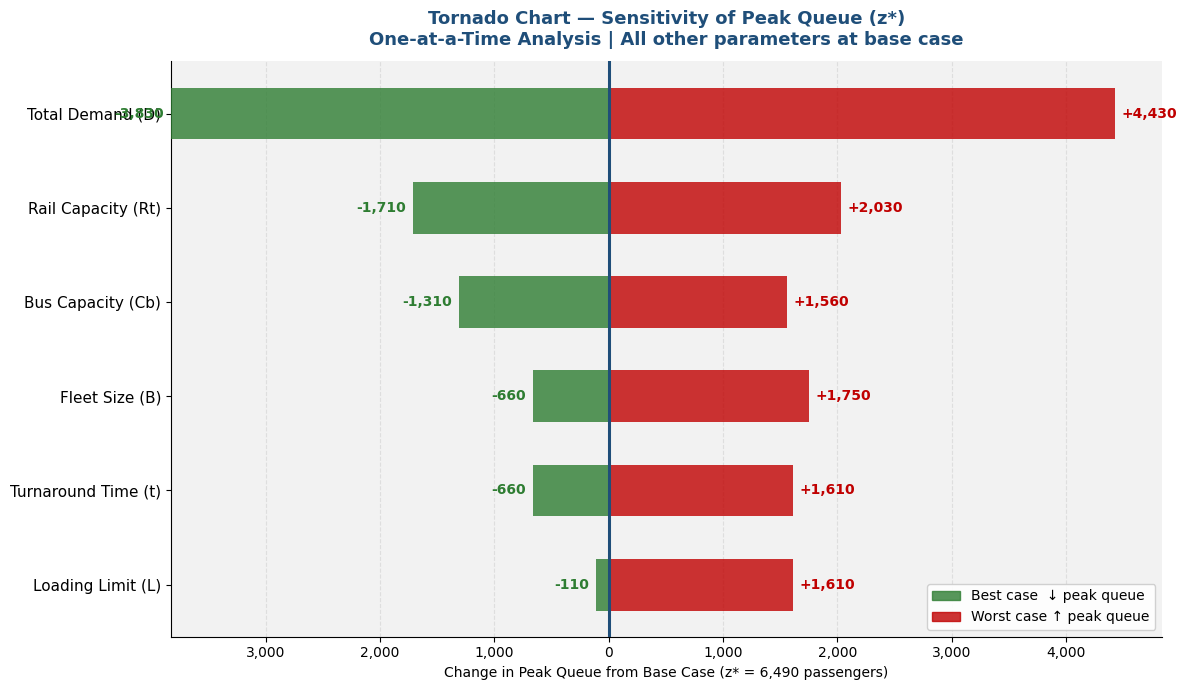

Saved: tornado_real.jpg


In [ ]:
# ============================================================
# SECTION 9 — Tornado Chart using real model output
# ============================================================

DARK_BLUE = "#1F4E79"
GREEN     = "#2E7D32"
RED       = "#C00000"
LGRAY     = "#F2F2F2"
WHITE     = "white"

# Compute min/max delta per parameter (bar lengths)
tornado_data = []
for label, results in oat_results.items():
    deltas    = [r['delta'] for r in results]
    min_delta = min(deltas)   # best improvement (most negative)
    max_delta = max(deltas)   # worst worsening (most positive)
    tornado_data.append((label, min_delta, max_delta))

# Sort by total range of impact (largest range at the top)
tornado_data.sort(key=lambda r: abs(r[1]) + abs(r[2]))

labels     = [d[0] for d in tornado_data]
min_deltas = [d[1] for d in tornado_data]
max_deltas = [d[2] for d in tornado_data]

fig, ax = plt.subplots(figsize=(12, 7), facecolor=WHITE)
ax.set_facecolor(LGRAY)

y = np.arange(len(labels))

for i, (min_d, max_d) in enumerate(zip(min_deltas, max_deltas)):
    ax.barh(i, abs(min_d), left=-abs(min_d), color=GREEN, alpha=0.80,
            height=0.55, zorder=3)
    ax.barh(i, max_d, left=0, color=RED, alpha=0.80,
            height=0.55, zorder=3)
    ax.text(-abs(min_d) - 60, i, f"{min_d:+,.0f}",
            ha="right", va="center", fontsize=10,
            color=GREEN, fontweight="bold")
    ax.text(max_d + 60, i, f"+{max_d:,.0f}",
            ha="left", va="center", fontsize=10,
            color=RED, fontweight="bold")

ax.axvline(0, color=DARK_BLUE, linewidth=2.2, zorder=5)
ax.set_yticks(y)
ax.set_yticklabels(labels, fontsize=11)
ax.set_xlabel(f"Change in Peak Queue from Base Case (z* = {BASE_Z:,} passengers)",
              fontsize=10)
ax.set_title("Tornado Chart — Sensitivity of Peak Queue (z*)\n"
             "One-at-a-Time Analysis | All other parameters at base case",
             fontsize=13, fontweight="bold", color=DARK_BLUE, pad=12)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(True, axis="x", alpha=0.3, linestyle="--")
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{int(abs(v)):,}"))

green_p = mpatches.Patch(color=GREEN, alpha=0.8, label="Best case  ↓ peak queue")
red_p   = mpatches.Patch(color=RED,   alpha=0.8, label="Worst case ↑ peak queue")
ax.legend(handles=[green_p, red_p], fontsize=10, loc="lower right", framealpha=0.9)

plt.tight_layout()
plt.savefig("tornado_real.jpg", dpi=180, bbox_inches="tight",
            facecolor=WHITE, format="jpeg", pil_kwargs={"quality": 95})
plt.show()
print("Saved: tornado_real.jpg")

In [ ]:
# ============================================================
# SECTION 10 — Fleet Size × Turnaround Time Heatmap
# Real values computed by solving the MILP for each combination
# ============================================================

fleet_values     = [30, 45, 60, 75, 90]        # values of B to test
turnaround_values = [30, 45, 60, 75, 90]        # values of tau (minutes) to test

# ── Run model for every (B, tau) pair ───────────────────────────────────────
print("Running Fleet × Turnaround heatmap...")
print(f"{'B':>6} {'tau':>6} {'h':>4} {'z* (Peak Queue)':>16}")
print("-" * 38)

Z_matrix = np.zeros((len(fleet_values), len(turnaround_values)))

for i, B_val in enumerate(fleet_values):
    for j, tau_val in enumerate(turnaround_values):

        run_params = BASE.copy()   # BASE dict defined in Section 8 above
        run_params['B']   = B_val
        run_params['tau'] = tau_val

        summary, _ = solve_dispatch_model(**run_params)
        z_star = summary['PeakQueue']
        Z_matrix[i, j] = z_star

        h_val = tau_val // 15
        marker = " <- base" if (B_val == 60 and tau_val == 60) else ""
        print(f"{B_val:>6} {tau_val:>6} {h_val:>4} {z_star:>16,.0f}{marker}")

print("\nDone! Drawing heatmap...")

Running Fleet × Turnaround heatmap...
     B    tau    h  z* (Peak Queue)
--------------------------------------
    30     30    2            6,490
    30     45    3            8,100
    30     60    4            8,240
    30     75    5            9,130
    30     90    6            9,750
    45     30    2            5,830
    45     45    3            6,450
    45     60    4            7,315
    45     75    5            8,305
    45     90    6            8,925
    60     30    2            5,830
    60     45    3            5,830
    60     60    4            6,490 <- base
    60     75    5            7,480
    60     90    6            8,100
    75     30    2            5,830
    75     45    3            5,830
    75     60    4            5,830
    75     75    5            6,655
    75     90    6            7,275
    90     30    2            5,830
    90     45    3            5,830
    90     60    4            5,830
    90     75    5            5,830
    90     90  

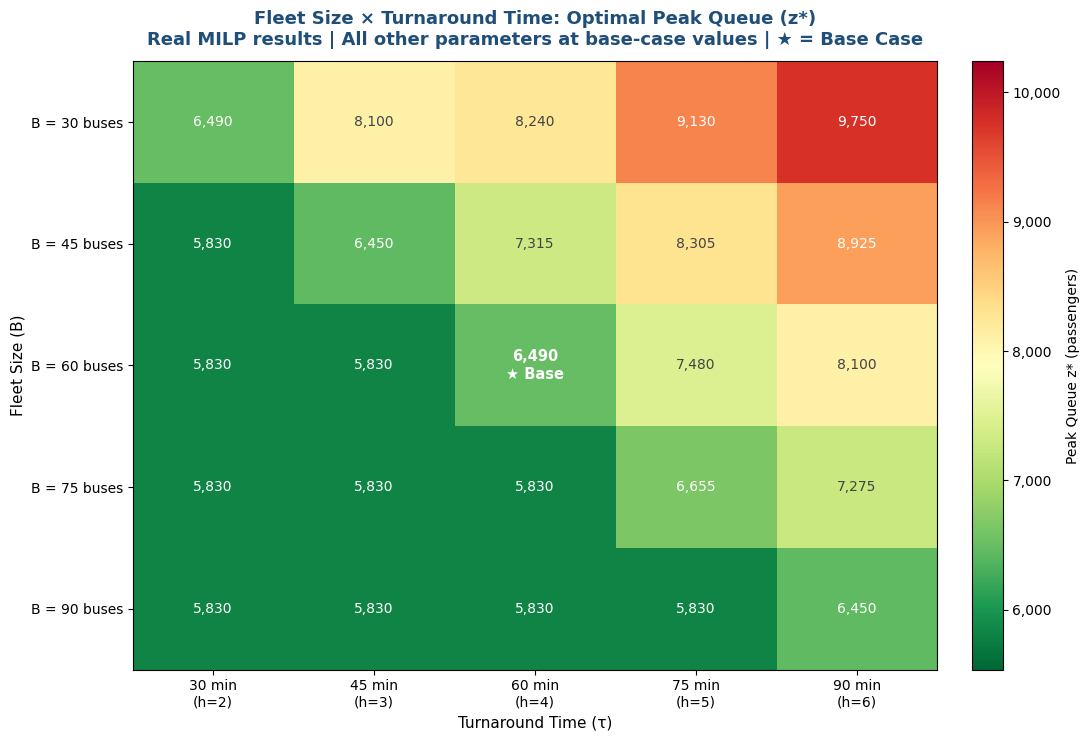

Saved: heatmap_real.jpg


In [ ]:
# ── Draw the heatmap ────────────────────────────────────────────────────────

DARK_BLUE = "#1F4E79"
DGRAY     = "#444444"
WHITE     = "white"

fig, ax = plt.subplots(figsize=(11, 7.5), facecolor=WHITE)

im = ax.imshow(Z_matrix, cmap="RdYlGn_r", aspect="auto",
               vmin=Z_matrix.min() * 0.95,
               vmax=Z_matrix.max() * 1.05)

cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("Peak Queue z* (passengers)", fontsize=10)
cbar.ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda v, _: f"{int(v):,}"))

# Axis labels
ax.set_xticks(range(len(turnaround_values)))
ax.set_xticklabels(
    [f"{t} min\n(h={t//15})" for t in turnaround_values], fontsize=10)
ax.set_yticks(range(len(fleet_values)))
ax.set_yticklabels(
    [f"B = {b} buses" for b in fleet_values], fontsize=10)
ax.set_xlabel("Turnaround Time (τ)", fontsize=11)
ax.set_ylabel("Fleet Size (B)", fontsize=11)

# Cell annotations
for i in range(len(fleet_values)):
    for j in range(len(turnaround_values)):
        val      = Z_matrix[i, j]
        is_base  = (fleet_values[i] == 60 and turnaround_values[j] == 60)

        # Use white text on dark cells, dark text on light cells
        norm_val = (val - Z_matrix.min()) / (Z_matrix.max() - Z_matrix.min())
        txt_color = WHITE if (norm_val > 0.70 or norm_val < 0.25) else DGRAY

        label  = f"{val:,.0f}\n★ Base" if is_base else f"{val:,.0f}"
        weight = "bold" if is_base else "normal"
        size   = 10.5 if is_base else 10

        ax.text(j, i, label,
                ha="center", va="center",
                fontsize=size, fontweight=weight, color=txt_color)

ax.set_title(
    "Fleet Size × Turnaround Time: Optimal Peak Queue (z*)\n"
    "Real MILP results | All other parameters at base-case values | ★ = Base Case",
    fontsize=13, fontweight="bold", color=DARK_BLUE, pad=12)

plt.tight_layout()
plt.savefig("heatmap_real.jpg", dpi=180, bbox_inches="tight",
            facecolor=WHITE, format="jpeg", pil_kwargs={"quality": 95})
plt.show()
print("Saved: heatmap_real.jpg")

/tmp/ipykernel_12683/1108559420.py:160: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.94])


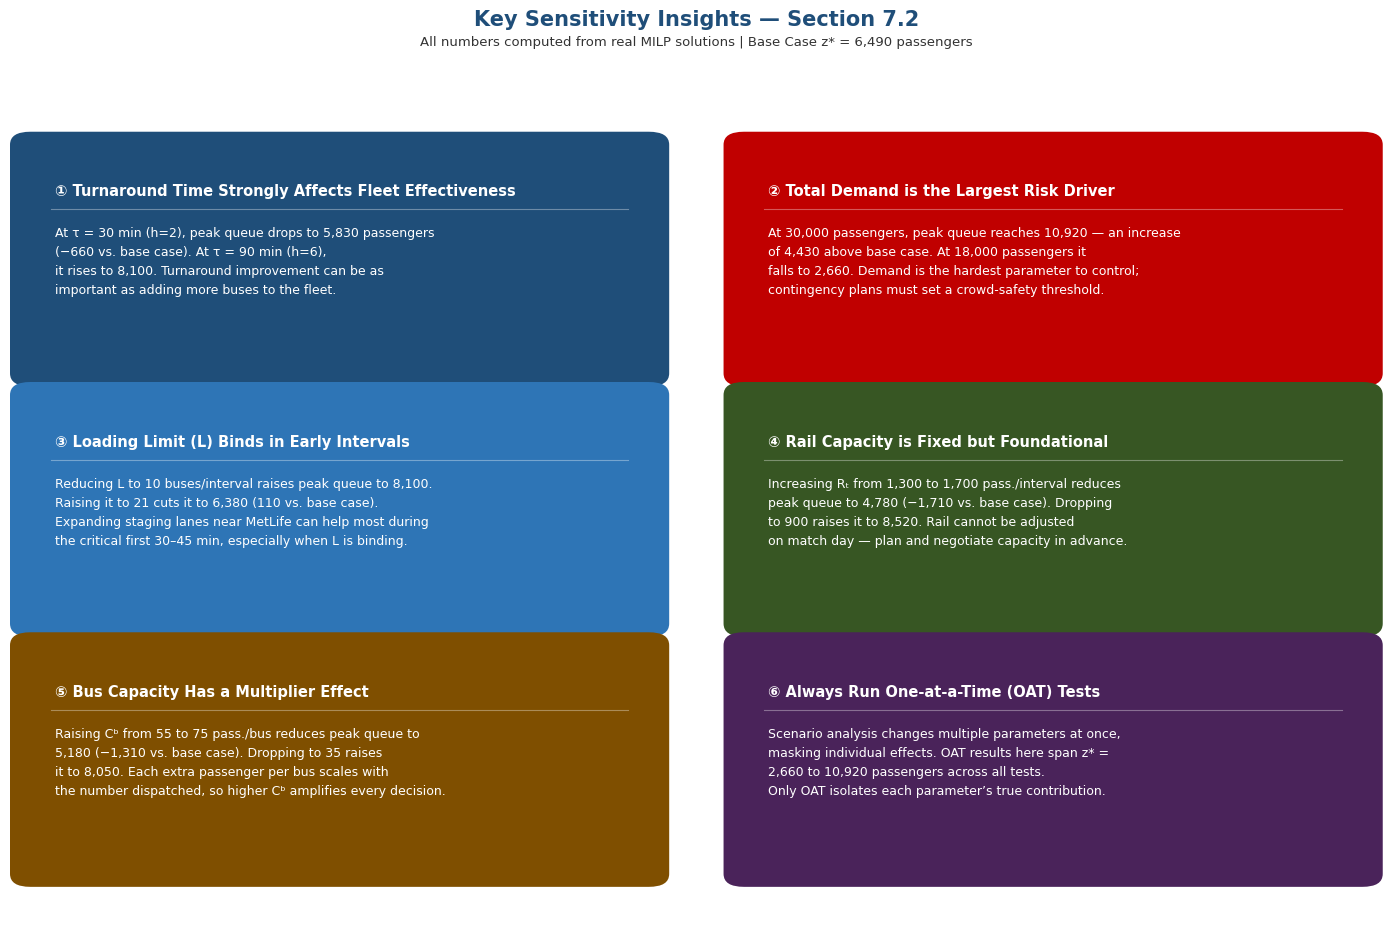

Saved: insights_real.jpg


In [ ]:
# ============================================================
# SECTION 11 — Key Sensitivity Insights Card Chart
# Text is generated automatically from real OAT model results
# ============================================================

import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch

# ── Extract real numbers from oat_results ───────────────────────────────────

def get_best_worst(label):
    """Returns (best_val, best_z, worst_val, worst_z) for a given parameter."""
    results = oat_results[label]
    best  = min(results, key=lambda r: r['z_star'])
    worst = max(results, key=lambda r: r['z_star'])
    return best['value'], int(best['z_star']), worst['value'], int(worst['z_star'])

# Pull real numbers for each card
tau_bv,  tau_bz,  tau_wv,  tau_wz  = get_best_worst('Turnaround Time (t)')
dem_bv,  dem_bz,  dem_wv,  dem_wz  = get_best_worst('Total Demand (D)')
L_bv,    L_bz,    L_wv,    L_wz    = get_best_worst('Loading Limit (L)')
rail_bv, rail_bz, rail_wv, rail_wz = get_best_worst('Rail Capacity (Rt)')
cb_bv,   cb_bz,   cb_wv,   cb_wz   = get_best_worst('Bus Capacity (Cb)')
B_bv,    B_bz,    B_wv,    B_wz    = get_best_worst('Fleet Size (B)')

tau_best_h  = tau_bv // 15
tau_worst_h = tau_wv // 15

# ── Build card content dynamically ──────────────────────────────────────────
cards = [
    {
        "color" : "#1F4E79",
        # Fix 2: title changed to reflect content more accurately
        "title" : "\u2460 Turnaround Time Strongly Affects Fleet Effectiveness",
        "body"  : (
            f"At \u03C4 = {tau_bv} min (h={tau_best_h}), peak queue drops to {tau_bz:,} passengers\n"
            # Fix 1: "from case" → "vs. base case"
            f"(\u2212{BASE_Z - tau_bz:,} vs. base case). At \u03C4 = {tau_wv} min (h={tau_worst_h}),\n"
            f"it rises to {tau_wz:,}. Turnaround improvement can be as\n"
            f"important as adding more buses to the fleet."
        ),
    },
    {
        "color" : "#C00000",
        "title" : "\u2461 Total Demand is the Largest Risk Driver",
        "body"  : (
            f"At {dem_wv:,} passengers, peak queue reaches {dem_wz:,} — an increase\n"
            f"of {dem_wz - BASE_Z:,} above base case. At {dem_bv:,} passengers it\n"
            f"falls to {dem_bz:,}. Demand is the hardest parameter to control;\n"
            f"contingency plans must set a crowd-safety threshold."
        ),
    },
    {
        "color" : "#2E75B6",
        "title" : "\u2462 Loading Limit (L) Binds in Early Intervals",
        "body"  : (
            f"Reducing L to {L_wv} buses/interval raises peak queue to {L_wz:,}.\n"
            f"Raising it to {L_bv} cuts it to {L_bz:,} ({BASE_Z - L_bz:,} vs. base case).\n"
            # Fix 3: "greatest benefit" → softer, conditional wording
            f"Expanding staging lanes near MetLife can help most during\n"
            f"the critical first 30\u201345 min, especially when L is binding."
        ),
    },
    {
        "color" : "#375623",
        "title" : "\u2463 Rail Capacity is Fixed but Foundational",
        "body"  : (
            f"Increasing R\u209C from 1,300 to {rail_bv:,} pass./interval reduces\n"
            f"peak queue to {rail_bz:,} (\u2212{BASE_Z - rail_bz:,} vs. base case). Dropping\n"
            f"to {rail_wv:,} raises it to {rail_wz:,}. Rail cannot be adjusted\n"
            f"on match day \u2014 plan and negotiate capacity in advance."
        ),
    },
    {
        "color" : "#7F4F00",
        "title" : "\u2464 Bus Capacity Has a Multiplier Effect",
        "body"  : (
            f"Raising C\u1D47 from 55 to {cb_bv} pass./bus reduces peak queue to\n"
            f"{cb_bz:,} (\u2212{BASE_Z - cb_bz:,} vs. base case). Dropping to {cb_wv} raises\n"
            f"it to {cb_wz:,}. Each extra passenger per bus scales with\n"
            f"the number dispatched, so higher C\u1D47 amplifies every decision."
        ),
    },
    {
        "color" : "#4A235A",
        "title" : "\u2465 Always Run One-at-a-Time (OAT) Tests",
        "body"  : (
            f"Scenario analysis changes multiple parameters at once,\n"
            f"masking individual effects. OAT results here span z* =\n"
            f"{min(r['z_star'] for res in oat_results.values() for r in res):,.0f}"
            f" to {max(r['z_star'] for res in oat_results.values() for r in res):,.0f} "
            f"passengers across all tests.\n"
            f"Only OAT isolates each parameter\u2019s true contribution."
        ),
    },
]

# ── Draw cards ──────────────────────────────────────────────────────────────
WHITE = "white"
DGRAY = "#333333"

fig, ax = plt.subplots(figsize=(14, 9.5), facecolor=WHITE)
ax.axis("off")

# Banner
fig.text(0.5, 0.985,
         "Key Sensitivity Insights \u2014 Section 7.2",
         ha="center", va="top", fontsize=15, fontweight="bold", color="#1F4E79")
fig.text(0.5, 0.958,
         "All numbers computed from real MILP solutions | Base Case z* = {:,} passengers".format(BASE_Z),
         ha="center", va="top", fontsize=9.5, color=DGRAY)

rule = fig.add_axes([0.04, 0.945, 0.92, 0.003])
rule.set_facecolor("#2E75B6"); rule.axis("off")

# Card grid: 2 columns, 3 rows
card_w = 0.455
card_h = 0.265
x_pos  = [0.01, 0.535]
y_pos  = [0.645, 0.355, 0.065]

for idx, card in enumerate(cards):
    x0 = x_pos[idx % 2]
    y0 = y_pos[idx // 2]
    bg = card["color"]

    rect = FancyBboxPatch(
        (x0, y0), card_w, card_h,
        boxstyle="round,pad=0.015", linewidth=0,
        facecolor=bg, transform=ax.transAxes,
        clip_on=False, zorder=2
    )
    ax.add_patch(rect)

    # Title
    ax.text(x0 + 0.018, y0 + card_h - 0.045,
            card["title"],
            ha="left", va="top",
            fontsize=10.5, fontweight="bold", color=WHITE,
            transform=ax.transAxes, zorder=3)

    # Divider line inside card
    line_y = y0 + card_h - 0.075
    ax.plot([x0 + 0.015, x0 + card_w - 0.015],
            [line_y, line_y],
            color=WHITE, alpha=0.35, linewidth=0.8,
            transform=ax.transAxes, zorder=3)

    # Body text
    ax.text(x0 + 0.018, y0 + card_h - 0.095,
            card["body"],
            ha="left", va="top",
            fontsize=9, color=WHITE,
            transform=ax.transAxes, zorder=3,
            linespacing=1.6)

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)

plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.savefig("insights_real.jpg", dpi=180, bbox_inches="tight",
            facecolor=WHITE, format="jpeg", pil_kwargs={"quality": 95})
plt.show()
print("Saved: insights_real.jpg")